In [1]:
import random

import cv2
from matplotlib import pyplot as plt

import albumentations as A
def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.imshow(image)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.1'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


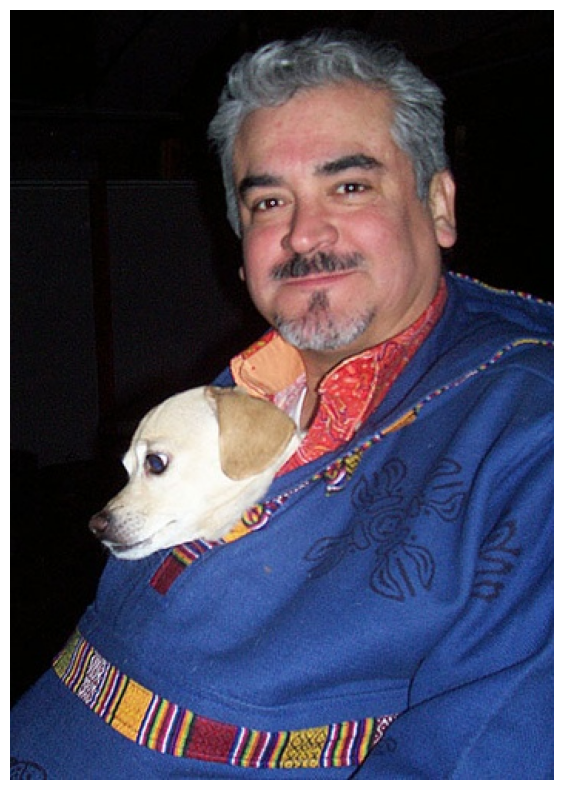

In [2]:
image = cv2.imread('./000001.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
visualize(image)

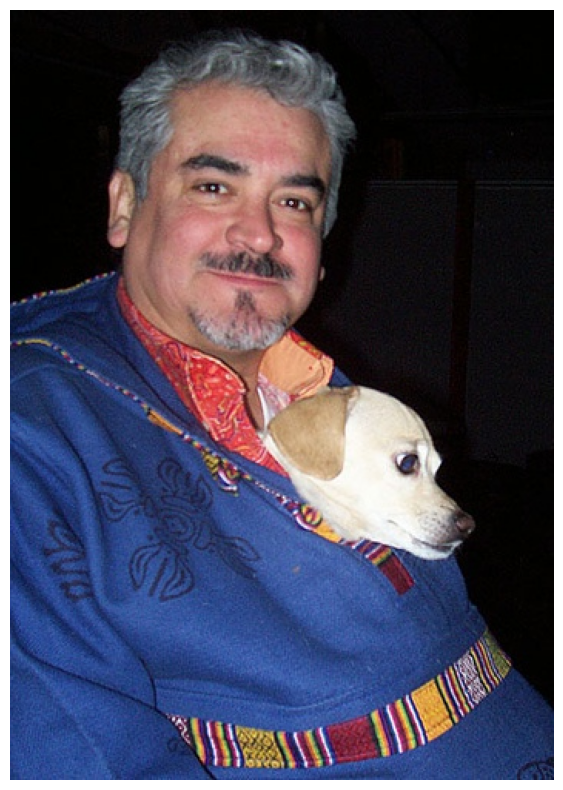

In [3]:
transform = A.HorizontalFlip(p=0.5)
random.seed(7)
augmented_image = transform(image=image)['image']
visualize(augmented_image)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\core\validation.py:45: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


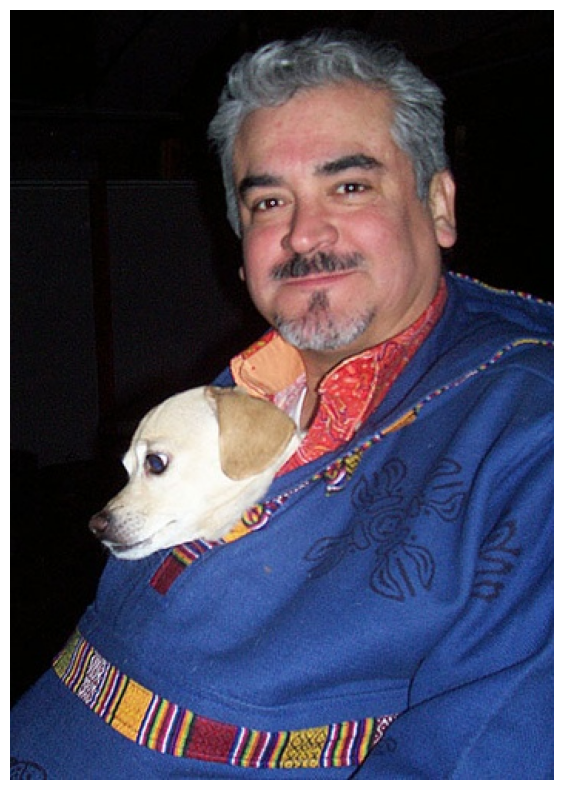

In [4]:
transform = A.ShiftScaleRotate(p=0.5)
random.seed(7)
augmented_image = transform(image=image)['image']
visualize(augmented_image)

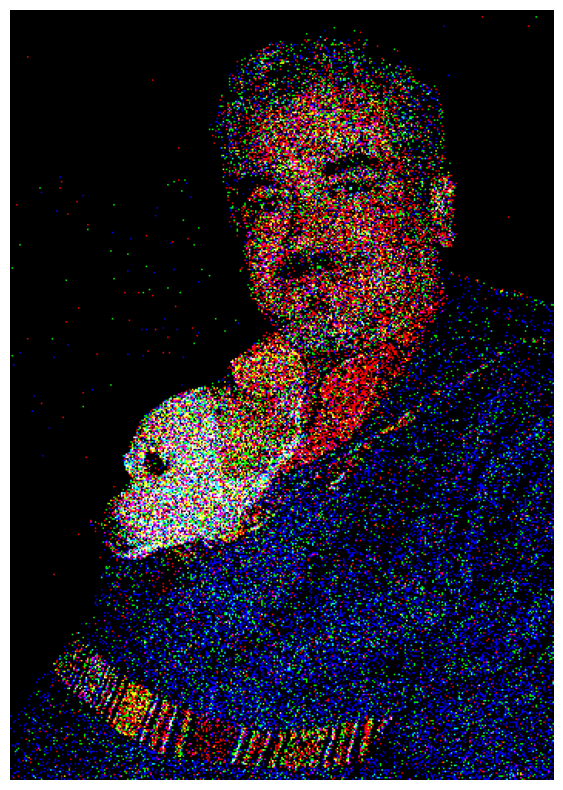

In [9]:
transform = A.Compose([
    A.ShotNoise(scale_range=(0.1, 1.0), p=1.0), 
    A.RandomBrightnessContrast(
        brightness_limit=0.3,  
        contrast_limit=0.3,    
        brightness_by_max=True, 
        ensure_safe_range=True, 
        p=1.0, 
    )
    ])
augmented = transform(image=image)["image"]
visualize(augmented)

In [ ]:
import os
import cv2
import albumentations as A
import numpy as np

def load_labels(label_path, image_shape):
    """
    Loads bounding boxes and their class labels from a text file if it exists.
    Expected format for each line in the file:
        class_id, x_center, y_center, width, height  (YOLO format)

    If no label file is found, a default bounding box covering the entire image is created.
    """
    bboxes = []
    class_labels = []
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    continue  
                class_id, x_center, y_center, width, height = map(float, parts)
                h, w, _ = image_shape
                x_min = (x_center - width / 2) * w
                y_min = (y_center - height / 2) * h
                abs_width = width * w
                abs_height = height * h
                bboxes.append([x_min, y_min, abs_width, abs_height])
                class_labels.append(str(int(class_id)))
    else:
        h, w, _ = image_shape
        bboxes = [[0, 0, w, h]]
        class_labels = ["object"]
        print(f"No label file found. Using default bounding box for image with shape {image_shape}.")
    
    return bboxes, class_labels

def save_labels(label_path, bboxes, class_labels, image_shape):
    """
    Saves bounding boxes and class labels to a text file in the format:
        class_id x_center y_center width height
    """
    h, w, _ = image_shape  
    with open(label_path, 'w') as f:
        for bbox, label in zip(bboxes, class_labels):
            x_min, y_min, width_abs, height_abs = bbox
            x_center = (x_min + width_abs / 2) / w
            y_center = (y_min + height_abs / 2) / h
            rel_width = width_abs / w
            rel_height = height_abs / h
            f.write(f"{label} {x_center} {y_center} {rel_width} {rel_height}\n")

LABEL_COLORS = {
    "11": (255, 0, 0),     
    "14": (0, 255, 0),     
    "object": (0, 0, 255)  
}


transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(
            hue_shift_limit=20, 
            sat_shift_limit=30, 
            val_shift_limit=20, 
            p=0.3
        ),
        A.Rotate(limit=30, p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        
    ],
    bbox_params=A.BboxParams(
        format='coco',           
        min_area=0,              
        min_visibility=0.0,      
        label_fields=['class_labels']  
    )
)

input_image_dir = "./images"
input_label_dir = "./labels"

output_image_dir = "augmented/images"
output_label_dir = "augmented/labels"
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

for img_file in os.listdir(input_image_dir):
    if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    image_path = os.path.join(input_image_dir, img_file)
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(input_label_dir, label_file)

    image = cv2.imread(image_path)
    if image is None:
        print("Error reading image:", image_path)
        continue

    bboxes, class_labels = load_labels(label_path, image.shape)

    try:
        augmented = transform(
            image=image, 
            bboxes=bboxes, 
            class_labels=class_labels
        )
    except Exception as e:
        print(f"Augmentation error for image {img_file}: {e}")
        continue

    aug_image = augmented['image']
    aug_bboxes = augmented['bboxes']
    aug_class_labels = augmented['class_labels']

    for bbox, label in zip(aug_bboxes, aug_class_labels):
        x_min, y_min, width_abs, height_abs = bbox
        x_min = int(x_min)
        y_min = int(y_min)
        width_abs = int(width_abs)
        height_abs = int(height_abs)

        color = LABEL_COLORS.get(label, (0, 0, 255))
        
        cv2.rectangle(
            aug_image, 
            (x_min, y_min), 
            (x_min + width_abs, y_min + height_abs), 
            color, 
            2
        )
        cv2.putText(
            aug_image, 
            label, 
            (x_min, max(y_min - 10, 0)), 
            cv2.FONT_HERSHEY_SIMPLEX, 
            0.9, 
            color, 
            2
        )

    output_image_path = os.path.join(output_image_dir, img_file)
    cv2.imwrite(output_image_path, aug_image)

    output_label_path = os.path.join(output_label_dir, label_file)
    save_labels(output_label_path, aug_bboxes, aug_class_labels, aug_image.shape)

print("Dataset augmentation complete!")


No label file found. Using default bounding box for image with shape (500, 486, 3).
No label file found. Using default bounding box for image with shape (281, 500, 3).
No label file found. Using default bounding box for image with shape (366, 500, 3).
No label file found. Using default bounding box for image with shape (375, 500, 3).
No label file found. Using default bounding box for image with shape (335, 500, 3).
No label file found. Using default bounding box for image with shape (333, 500, 3).
No label file found. Using default bounding box for image with shape (375, 500, 3).
No label file found. Using default bounding box for image with shape (375, 500, 3).
No label file found. Using default bounding box for image with shape (375, 500, 3).
No label file found. Using default bounding box for image with shape (375, 500, 3).
No label file found. Using default bounding box for image with shape (500, 334, 3).
No label file found. Using default bounding box for image with shape (375, 5